In [13]:

!pip -q install pandas numpy matplotlib seaborn scikit-learn statsmodels joblib plotly

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
np.random.seed(42)


In [14]:

from google.colab import files

uploaded = files.upload()
FILE_NAME = list(uploaded.keys())[0]
print("Using:", FILE_NAME)


Saving HHS_Unaccompanied_Alien_Children_Program.csv to HHS_Unaccompanied_Alien_Children_Program (1).csv
Using: HHS_Unaccompanied_Alien_Children_Program (1).csv


In [15]:

raw = pd.read_csv(FILE_NAME)

print("Original shape:", raw.shape)
display(raw.head())
print("\nColumns:")
print(raw.columns.tolist())
print("\nMissing values:")
display(raw.isna().sum())


Original shape: (1170, 6)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0



Columns:
['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']

Missing values:


,0
Date,450
Children apprehended and placed in CBP custody*,450
Children in CBP custody,450
Children transferred out of CBP custody,450
Children in HHS Care,450
Children discharged from HHS Care,450


In [16]:

df = raw.dropna(how="all").copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
numeric_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )
df = df.dropna(subset=["Date"]).sort_values("Date")
df = df.drop_duplicates(subset="Date")

print("After cleaning:", df.shape)
display(df.head())
display(df.describe())


After cleaning: (720, 6)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
719,2023-01-12,33.0,53.0,34.0,6566,436.0
718,2023-01-22,32.0,49.0,39.0,7122,227.0
717,2023-01-23,32.0,50.0,39.0,7280,181.0
716,2023-01-24,47.0,42.0,47.0,7433,175.0
715,2023-01-25,20.0,22.0,41.0,7538,180.0


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841


In [17]:

df = df.set_index("Date")

daily = df.asfreq("D")

daily[numeric_cols] = daily[numeric_cols].interpolate(method="time")
daily[numeric_cols] = daily[numeric_cols].ffill().bfill()

print("Daily dataset:", daily.shape)
print("Date range:", daily.index.min().date(), "to", daily.index.max().date())
display(daily.head())


Daily dataset: (1075, 5)
Date range: 2023-01-12 to 2025-12-21


,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-13,32.9,52.6,34.5,6621.6,415.1
2023-01-14,32.8,52.2,35.0,6677.2,394.2
2023-01-15,32.7,51.8,35.5,6732.8,373.3
2023-01-16,32.6,51.4,36.0,6788.4,352.4


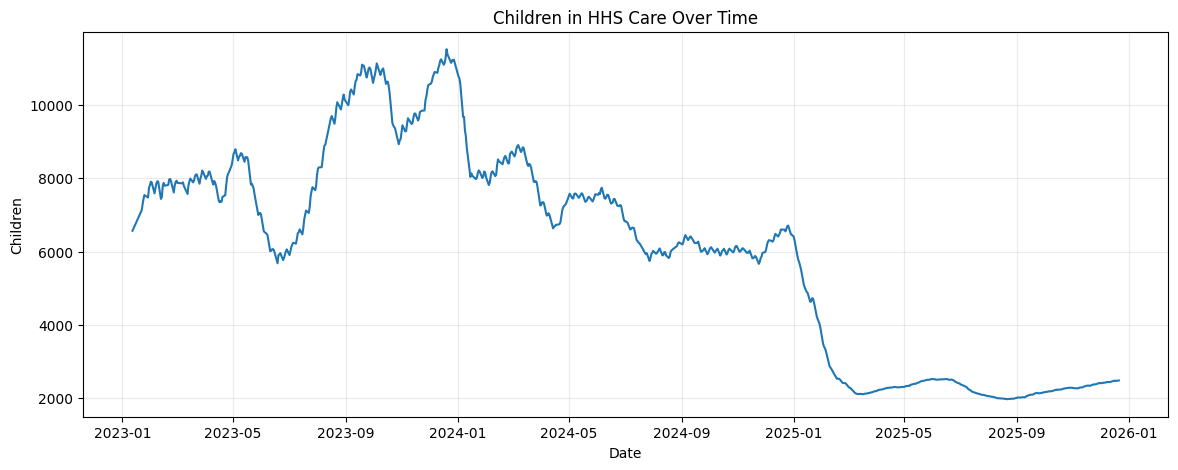

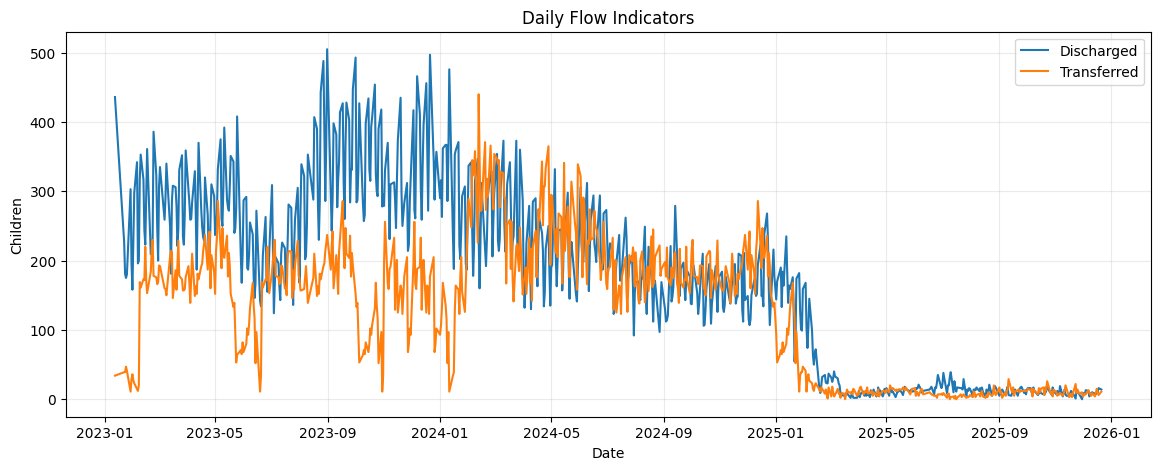

In [18]:

plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily["Children in HHS Care"])
plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children")
plt.grid(alpha=0.25)

plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily["Children discharged from HHS Care"], label="Discharged")
plt.plot(daily.index, daily["Children transferred out of CBP custody"], label="Transferred")
plt.title("Daily Flow Indicators")
plt.xlabel("Date")
plt.ylabel("Children")
plt.legend()
plt.grid(alpha=0.25)



In [19]:

def make_features(data, target):
    X = pd.DataFrame(index=data.index)

    for lag in [1, 2, 3, 7, 14, 21, 28]:
        X[f"lag_{lag}"] = data[target].shift(lag)

    for window in [7, 14, 28]:
        shifted = data[target].shift(1)
        X[f"roll_mean_{window}"] = shifted.rolling(window).mean()
        X[f"roll_std_{window}"] = shifted.rolling(window).std()

    X["day_of_week"] = X.index.dayofweek
    X["month"] = X.index.month
    X["day_of_year"] = X.index.dayofyear
    X["week_of_year"] = X.index.isocalendar().week.astype(int).values

    return X

def make_feature_row(history, date):
    s = pd.Series(history, index=pd.to_datetime(history.index)).sort_index()
    row = {}

    for lag in [1, 2, 3, 7, 14, 21, 28]:
        row[f"lag_{lag}"] = float(s.iloc[-lag])

    for window in [7, 14, 28]:
        vals = s.iloc[-window:]
        row[f"roll_mean_{window}"] = float(vals.mean())
        row[f"roll_std_{window}"] = float(vals.std()) if len(vals) > 1 else 0.0

    row["day_of_week"] = date.dayofweek
    row["month"] = date.month
    row["day_of_year"] = date.dayofyear
    row["week_of_year"] = int(date.isocalendar().week)

    return pd.DataFrame([row], index=[date])

def recursive_rf_forecast(model, history, horizon):
    history = history.copy()
    future = []

    for _ in range(horizon):
        next_date = history.index[-1] + pd.Timedelta(days=1)
        X_next = make_feature_row(history, next_date)
        pred = float(model.predict(X_next)[0])
        pred = max(0, pred)
        future.append((next_date, pred))
        history.loc[next_date] = pred

    return pd.Series(dict(future), name="forecast")

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), 1e-8)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def metric_row(name, actual, pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred)),
        "MAPE (%)": mape(actual, pred)
    }


In [20]:
TARGETS = {
    "care_load": "Children in HHS Care",
    "discharge": "Children discharged from HHS Care",
    "transfer": "Children transferred out of CBP custody"
}

feature_sets = {}
target_sets = {}

for key, target in TARGETS.items():
    X = make_features(daily, target)
    y = daily[target]
    valid = X.notna().all(axis=1)

    feature_sets[key] = X.loc[valid]
    target_sets[key] = y.loc[valid]

split_ratio = 0.80
splits = {}

for key in TARGETS:
    X = feature_sets[key]
    y = target_sets[key]
    split = int(len(X) * split_ratio)
    splits[key] = (X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:])

print("80/20 chronological split created.")


80/20 chronological split created.


In [21]:

comparison_rows = []
models_final = {}
validation_residuals = {}

for key, target in TARGETS.items():
    X_train, X_test, y_train, y_test = splits[key]

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    # Naive persistence
    naive_pred = y_test.shift(0).copy()
    naive_pred[:] = y_train.iloc[-1]

    full_y = pd.concat([y_train, y_test])
    naive_pred = full_y.shift(1).loc[y_test.index]

    # SARIMA
    sarima = SARIMAX(
        y_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    sarima_pred = sarima.get_forecast(steps=len(y_test)).predicted_mean

    comparison_rows += [
        metric_row(f"{key} - Random Forest", y_test, rf_pred),
        metric_row(f"{key} - Naive", y_test, naive_pred),
        metric_row(f"{key} - SARIMA", y_test, sarima_pred)
    ]

    validation_residuals[key] = {
        "Random Forest": (y_test.values - rf_pred).tolist(),
        "Naive": (y_test.values - naive_pred.values).tolist(),
        "SARIMA": (y_test.values - sarima_pred.values).tolist()
    }

    models_final[key] = {}

    rf_final = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf_final.fit(feature_sets[key], target_sets[key])
    models_final[key]["Random Forest"] = rf_final

    sarima_final = SARIMAX(
        daily[target],
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    models_final[key]["SARIMA"] = sarima_final

    models_final[key]["Naive"] = None

comparison = pd.DataFrame(comparison_rows)
display(comparison.sort_values(["Model"]))


,Model,MAE,RMSE,MAPE (%)
1,care_load - Naive,6.659048,8.275883,2.958635e-01
0,care_load - Random Forest,42.301215,66.066195,2.023261e+00
2,care_load - SARIMA,228.216602,278.732654,1.066629e+01
4,discharge - Naive,3.688571,4.986379,1.111111e+08
3,discharge - Random Forest,3.557089,4.844142,3.648480e+08
5,discharge - SARIMA,53.756521,59.847651,3.720871e+09
7,transfer - Naive,3.085714,4.282135,6.190477e+08
6,transfer - Random Forest,4.648970,5.552387,1.098160e+09
8,transfer - SARIMA,18.762529,22.963022,2.465329e+08


,Model,MAE,RMSE,MAPE (%)
0,care_load - Random Forest,42.301215,66.066195,2.023261
1,care_load - Naive,6.659048,8.275883,0.295864
2,care_load - SARIMA,228.216602,278.732654,10.666294


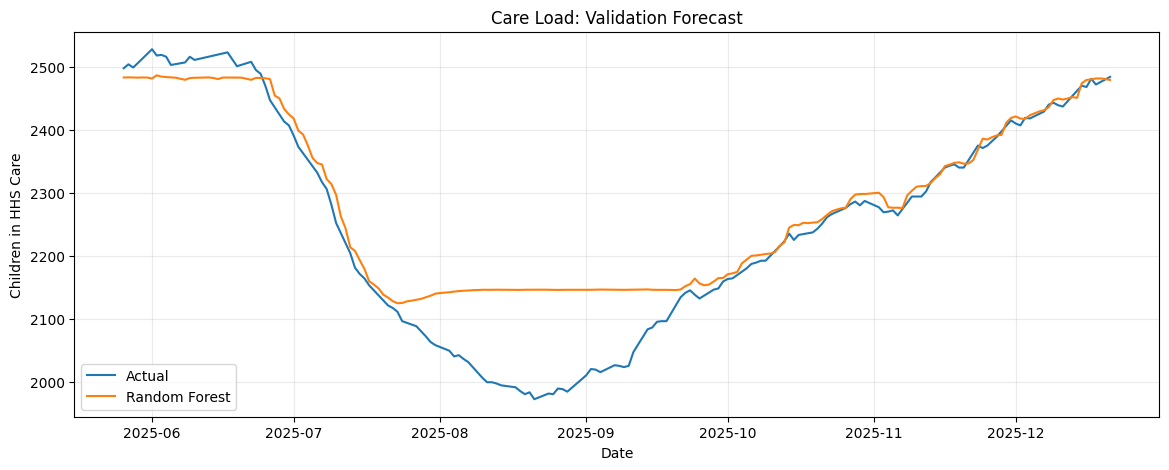

In [22]:

care_comparison = comparison[comparison["Model"].str.startswith("care_load")].copy()
display(care_comparison)

key = "care_load"
X_train, X_test, y_train, y_test = splits[key]
rf_check = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf_check.fit(X_train, y_train)
pred = rf_check.predict(X_test)

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, pred, label="Random Forest")
plt.title("Care Load: Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [23]:

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

daily.to_csv(f"{ARTIFACT_DIR}/daily_data.csv")

joblib.dump(models_final, f"{ARTIFACT_DIR}/models.pkl")

joblib.dump(validation_residuals, f"{ARTIFACT_DIR}/validation_residuals.pkl")

comparison.to_csv(f"{ARTIFACT_DIR}/model_comparison.csv", index=False)

metadata = {
    "last_date": str(daily.index.max().date()),
    "targets": TARGETS,
    "frequency": "D",
    "random_seed": 42
}
joblib.dump(metadata, f"{ARTIFACT_DIR}/metadata.pkl")

print("Saved:")
for root, dirs, files_ in os.walk(ARTIFACT_DIR):
    for f in files_:
        print(os.path.join(root, f))


Saved:
artifacts/metadata.pkl
artifacts/validation_residuals.pkl
artifacts/daily_data.csv
artifacts/model_comparison.csv
artifacts/models.pkl


In [24]:

!zip -r uac_streamlit_artifacts.zip artifacts
from google.colab import files
files.download("uac_streamlit_artifacts.zip")


updating: artifacts/ (stored 0%)
updating: artifacts/metadata.pkl (deflated 23%)
updating: artifacts/validation_residuals.pkl (deflated 33%)
updating: artifacts/daily_data.csv (deflated 74%)
updating: artifacts/model_comparison.csv (deflated 46%)
updating: artifacts/models.pkl (deflated 62%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>